<a href="https://colab.research.google.com/github/ugurdurak3455-boop/Git-Course-Reports/blob/main/%D0%9E%D0%B1%D1%80%D0%B0%D0%B7%D0%B5%D1%86_%D1%80%D1%80_%D0%B8%D0%BD%D1%82%D0%B5%D0%B3%D1%80%D0%B0%D0%BB%D1%8B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt  # библиотека для визуализации
import sympy as sp  # библиотека для символьных вычислений
from scipy.integrate import quad  # для численного вычисления интегралов

# 1 задание

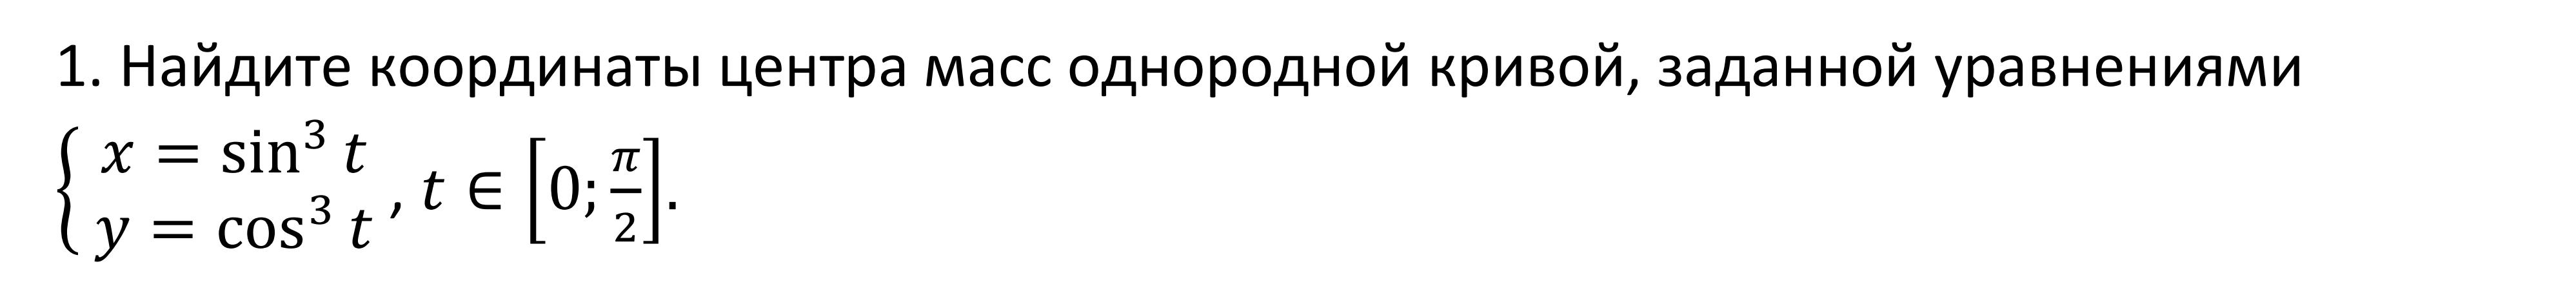

(это часть астроиды)

### Вычисление

In [ ]:
t = sp.Symbol('t', real = True)

x = sp.sin(t)**3
y = sp.cos(t)**3

t1, t2 = 0, sp.pi/2

Используем формулы для координат центра масс однородной плоской кривой, заданной параметрически:

$$x_c=\frac1L\int_{t_1}^{t_2}x\left(t\right)\sqrt{\left(x'_t\left(t\right)\right)^2+\left(y'_t\left(t\right)\right)^2}dt,$$

$$y_c=\frac1L\int_{t_1}^{t_2}y\left(t\right)\sqrt{\left(x'_t\left(t\right)\right)^2+\left(y'_t\left(t\right)\right)^2}dt,$$
где длина кривой
$$L=\int_{t_1}^{t_2}\sqrt{\left(x'_t\left(t\right)\right)^2+\left(y'_t\left(t\right)\right)^2}dt.$$

In [ ]:
# Выше я использовал markdown с формулами в latex. Если это сложно, можно писать обычные комментарии:
# dl = sqrt((x')^2 + (y')^2) dt
dl = sp.sqrt(sp.diff(x, t)**2 + sp.diff(y, t)**2).simplify()

L = sp.integrate(dl, (t, t1, t2))

x_c = 1/L * sp.integrate(x * dl, (t, t1, t2))
print('x-координата центра масс:')
x_c

x-координата центра масс:


2/5

In [ ]:
y_c = 1/L * sp.integrate(y * dl, (t, t1, t2))
print('y-координата центра масс:')
y_c

y-координата центра масс:


2/5

### Визуализация

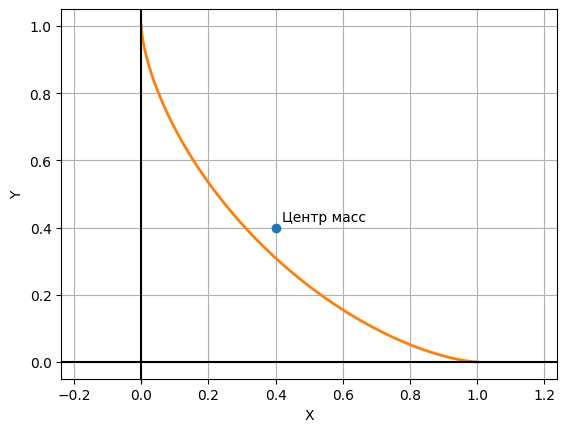

In [ ]:
t = np.linspace(0, np.pi/2, 100)
x = np.sin(t)**3
y = np.cos(t)**3

plt.plot(x_c, y_c, 'o')
plt.annotate('Центр масс', (x_c, y_c), (x_c + .02, y_c + .02))

plt.plot(x, y, linewidth=2)
plt.axhline(0, color='black')
plt.axvline(0, color='black')
plt.xlabel('X')
plt.ylabel('Y')
plt.axis('equal')
plt.grid()

# 2 задание

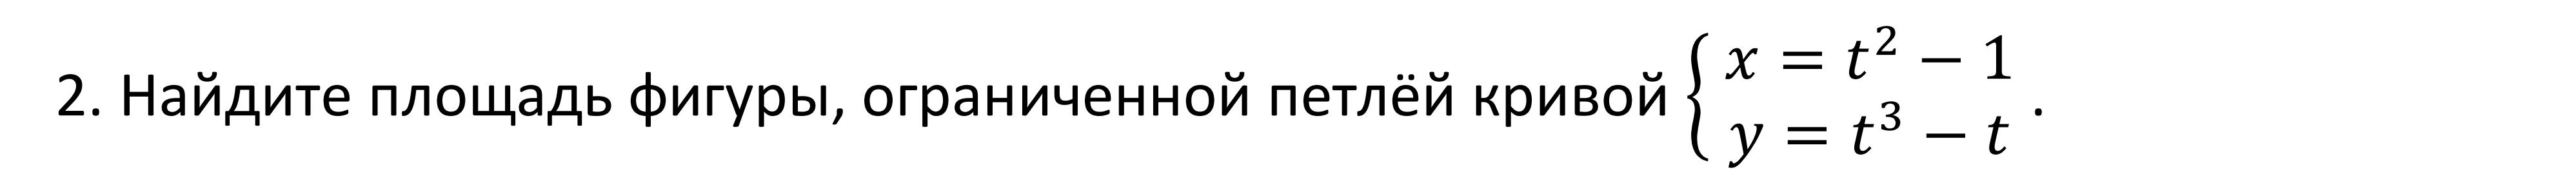

### Вычисление

Самое сложное в задаче — определить пределы интегрирования. Они определяются из условия образования петли: при $t_1 \ne t_2$ должно выполняться

$$
\begin{cases}
    x\left(t_1\right) = x\left(t_2\right), \\
    y\left(t_1\right) = y\left(t_2\right).
\end{cases}
$$

В нашем случае

$$
\begin{cases}
    t_1^2 - 1 = t_2^2 - 1, \\
    t_1^3 - t_1 = t_2^3 - t_2.
\end{cases}
$$

Эту систему тоже можно решить с помощью символьной арифметики:

In [ ]:
t1, t2 = sp.symbols('t1 t2')

eq1 = sp.Eq(t1**2 - 1, t2**2 - 1)
eq2 = sp.Eq(t1**3 - t1, t2**3 - t2)

sp.solve((eq1, eq2), (t1, t2))

[(t2, t2), (-1, 1), (0, 0), (1, -1)]

Выберем решение с $t_1 \ne t_2$:

In [ ]:
t1, t2 = -1, 1

Используем формулу для площади параметрически заданной кривой:

$$S=\left|\int_{t_1}^{t_2}y\left(t\right)x'_t\left(t\right)dt\right|.$$

In [ ]:
t = sp.Symbol('t', real = True)

x = t**2 - 1
y = t**3 - t

print('Ответ:')
sp.integrate(sp.Abs(y * sp.diff(x, t)), (t, t1, t2))

Ответ:


8/15

### Визуализация

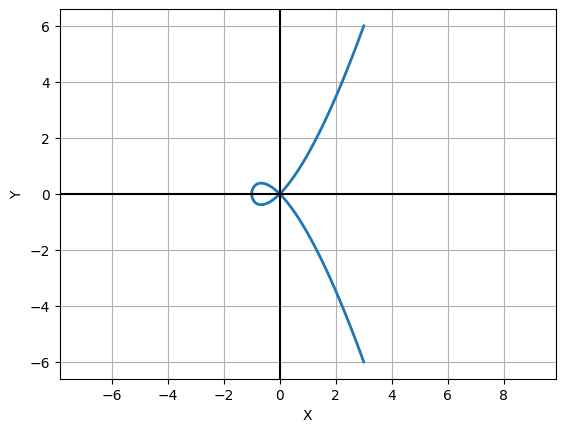

In [ ]:
t = np.linspace(-2, 2, 100)
x = t**2 - 1
y = t**3 - t

plt.plot(x, y, linewidth=2)
plt.axhline(0, color='black')
plt.axvline(0, color='black')
plt.xlabel('X')
plt.ylabel('Y')
plt.axis('equal')
plt.grid()

# 3 задание

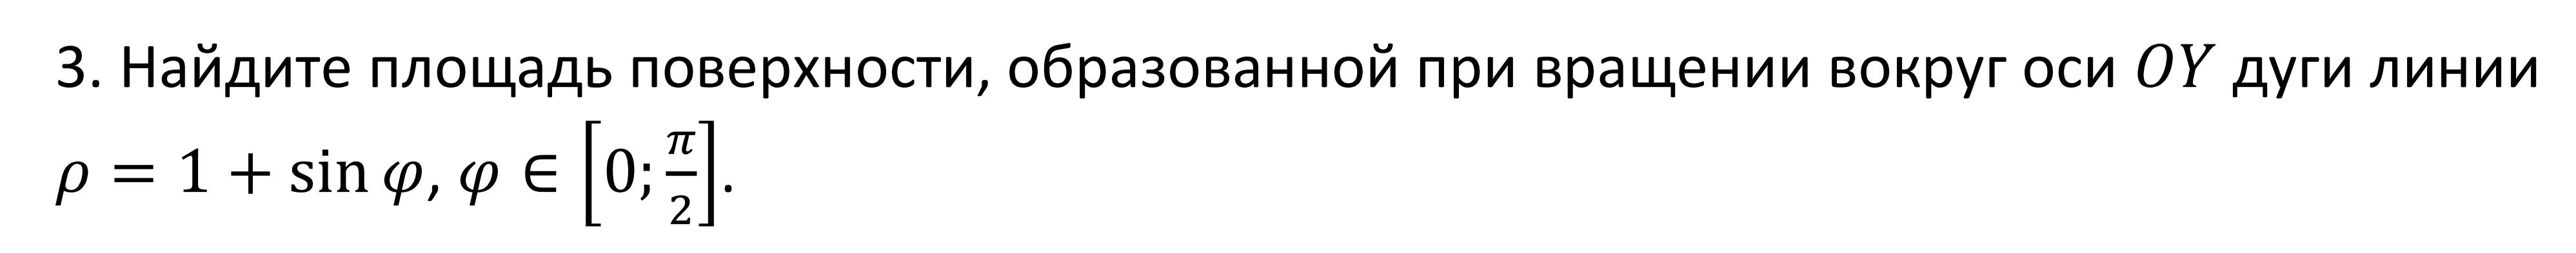

(это часть кардиоиды)

### Вычисление

In [ ]:
phi = sp.Symbol('phi', real = True)
rho = 1 + sp.sin(phi)

Используем формулу для площади поверхности, образованной вращением вокруг оси $OY$ кривой, заданной в полярных координатах:

$$S=2\pi\int_{\phi_1}^{\phi_2}\rho\left(\phi\right)\cos\phi\sqrt{\left(\rho^2\left(\phi\right)+\rho'_\phi\left(\phi\right)\right)^2}d\phi.$$

In [ ]:
integrand = 2 * sp.pi * rho * sp.cos(phi) * sp.sqrt(rho**2 + sp.diff(rho, phi)**2)  # выражение под интегралом
integrand

2*pi*sqrt((sin(phi) + 1)**2 + cos(phi)**2)*(sin(phi) + 1)*cos(phi)

In [ ]:
integrand = integrand.simplify()  # перед вычислением часто необходимо сначала его упростить
integrand

2*sqrt(2)*pi*(sin(phi) + 1)**(3/2)*cos(phi)

In [ ]:
answer = sp.integrate(integrand, (phi, 0, sp.pi/2))
print('Ответ:')
answer

Ответ:


-4*sqrt(2)*pi/5 + 32*pi/5

### Визуализация

Исходная кривая в плоскости XOY:

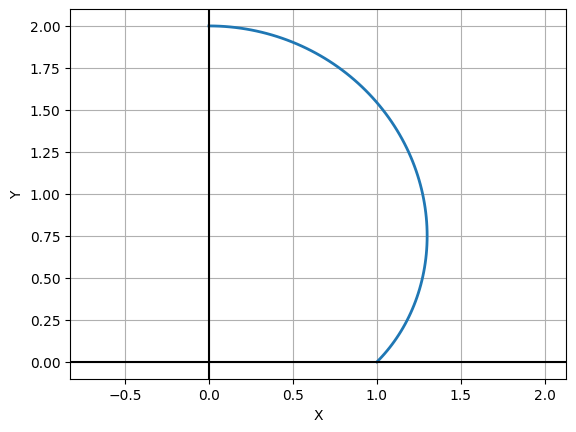

In [ ]:
phi = np.linspace(0, np.pi/2, 100)
rho = 1 + np.sin(phi)

x = rho * np.cos(phi)
y = rho * np.sin(phi)

plt.plot(x, y, linewidth=2)
plt.axhline(0, color='black')
plt.axvline(0, color='black')
plt.xlabel('X')
plt.ylabel('Y')
plt.axis('equal')
plt.grid()

Вращаем ее вокруг OY:

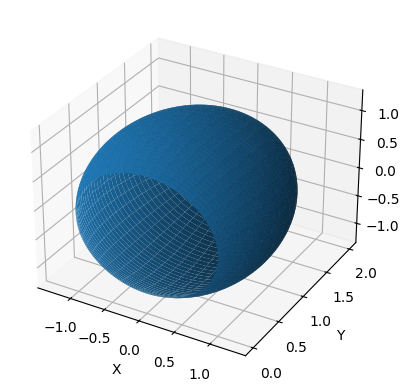

In [ ]:
alpha = np.linspace(0, 2*np.pi, 100)[:, np.newaxis]

ax = plt.subplot(projection='3d')
# при повороте вокруг OY на угол alpha новые координаты x', y', z' так выражаются через старые (z=0):
ax.plot_surface(x * np.cos(alpha),  # x' = x * cos(alpha)
                y,                  # y' = y
                x * np.sin(alpha))  # z' = x * sin(alpha)
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

# 4 задание

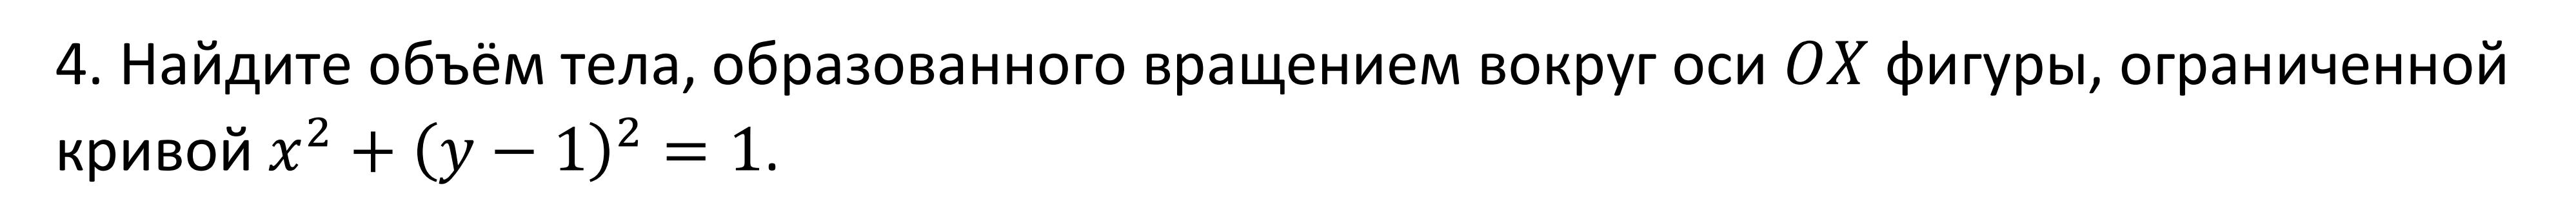

### Визуализация

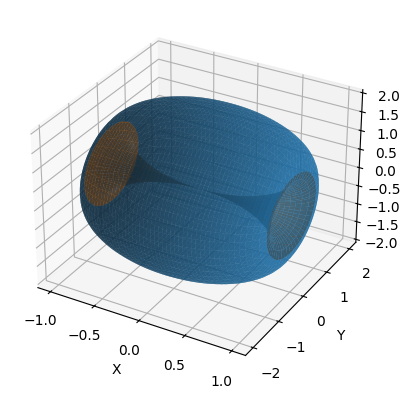

In [ ]:
x = np.linspace(-1, 1, 100)  # исходная кривая - окружность радиуса 1 с центром в (0, 1), пределы по x от -1 до 1
# выражая y через x, при извлечении корня получаем +-. Это дает верхнюю и нижнюю часть окружности. Будем вращать эти части отдельно
y1 = 1 + np.sqrt(1 - x**2)
y2 = 1 - np.sqrt(1 - x**2)
alpha = np.linspace(0, 2*np.pi, 100)[:, np.newaxis]

ax = plt.subplot(projection='3d')
# при повороте вокруг OX на угол alpha новые координаты x', y', z' так выражаются через старые (z=0):
ax.plot_surface(x,                   # x' = x
                y1 * np.cos(alpha),  # y' = y * cos(alpha)
                y1 * np.sin(alpha),  # z' = x * sin(alpha)
                alpha = 0.7)         # добавляем прозрачность
ax.plot_surface(x,
                y2 * np.cos(alpha),
                y2 * np.sin(alpha))
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

### Вычисление

Вычитаем из объема внешнего тела объем внутреннего:

$$V = \pi\int_a^b y_1^2(x)dx - \pi\int_a^b y_2^2(x)dx$$

In [ ]:
x = sp.Symbol('x', real = True)
y1 = 1 + sp.sqrt(1 - x**2)
y2 = 1 - sp.sqrt(1 - x**2)

print('Ответ:')
answer = sp.integrate(sp.pi * (y1**2 - y2**2), (x, -1, 1))
answer

Ответ:


2*pi**2

In [ ]:
answer.n()

19.7392088021787

### Вычисление. 2 способ

Если интеграл сложный, то его можно вычислить численно:

In [ ]:
def f(x):
    y1 = 1 + np.sqrt(1 - x**2)
    y2 = 1 - np.sqrt(1 - x**2)
    return np.pi * (y1**2 - y2**2)

answer_numerical, error = quad(f, -1, 1)
answer_numerical

19.739208802178734